# Data Preprocessing 2 - The scikit-learn Way

The **scikit-learn** half: the same preprocessing goals as notebook 01, but done with `sklearn` transformers that fit on training data and apply cleanly inside pipelines - the leakage-safe, production-ready approach. Covers imputers, scalers, encoders, train/test splitting, feature selection, dimensionality reduction, class imbalance (SMOTE), full `Pipeline` / `ColumnTransformer` workflows, and model persistence.

**Dataset:** Titanic (loaded from seaborn). This notebook is self-contained - it reloads the data below so you can run it on its own.

> Prerequisite intuition lives in **`01_pandas_fundamentals.ipynb`**.

# 0) Setup and Imports

Before running this notebook, make sure all required packages are installed.
Run the following command in your terminal or in a notebook cell:

```
pip install numpy pandas seaborn scikit-learn imbalanced-learn joblib matplotlib
```

> **Note:** `imbalanced-learn` is a separate package from scikit-learn. It must be installed explicitly — it is not included with the standard scikit-learn install.

In [1]:
import numpy as np
# NumPy is used for numerical operations (arrays, math functions, etc.)

# NumPy is used for numerical operations (arrays, math functions, etc.)

import pandas as pd
# Pandas is used to load, inspect, clean, and manipulate tabular datasets (DataFrames)

import seaborn as sns
# Seaborn is used here to load the built-in Titanic dataset with a single line of code
# No file download or Kaggle account required

from sklearn.model_selection import train_test_split
# Used to split the dataset into training and testing sets

from sklearn.impute import SimpleImputer, KNNImputer
# SimpleImputer: fills missing values using mean, median, mode, or constant
# KNNImputer: fills missing values using nearest neighbors (more advanced)

from sklearn.preprocessing import (
    StandardScaler,    # Standardizes features (mean=0, std=1)
    MinMaxScaler,      # Scales features to a fixed range (usually 0 to 1)
    RobustScaler,      # Scales using median and IQR (robust to outliers)
    MaxAbsScaler,      # Scales by maximum absolute value
    Normalizer,        # Normalizes each row to unit length
    LabelEncoder       # Encodes a categorical column into integer labels
)

from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder
# OneHotEncoder: converts categories into binary (0/1) columns
# OrdinalEncoder: converts categories into ordered integer labels

from sklearn.compose import ColumnTransformer
# Applies different preprocessing steps to different column types

from sklearn.pipeline import Pipeline
# Chains preprocessing steps and the ML model into one workflow

from sklearn.linear_model import LinearRegression, LogisticRegression
# LinearRegression: predicts continuous values (e.g., fare)
# LogisticRegression: predicts binary classes (e.g., survived)

from sklearn.feature_selection import VarianceThreshold, RFE
# VarianceThreshold: removes nearly constant (low-variance) features
# RFE: Recursive Feature Elimination — removes least important features step by step

from sklearn.decomposition import PCA, TruncatedSVD
# PCA: reduces dimensionality while keeping maximum information
# TruncatedSVD: similar to PCA, works well on sparse data too

from sklearn.metrics import (
    r2_score,               # Regression: proportion of variance explained
    mean_squared_error,     # Regression: average squared prediction error
    accuracy_score,         # Classification: proportion of correct predictions
    classification_report   # Classification: precision, recall, F1 per class
)

from imblearn.over_sampling import SMOTE
# SMOTE: Synthetic Minority Over-sampling Technique
# Creates synthetic samples for the minority class to fix class imbalance

import joblib
# Saves and loads trained models and preprocessing pipelines
import matplotlib.pyplot as plt
# matplotlib is used for all visualizations throughout the notebook

sns.set_theme(style="whitegrid", palette="muted")
# Apply a clean consistent visual theme to all plots
from sklearn.metrics import confusion_matrix
# Used for building the confusion matrix visualization in Section 20.3


# Dataset Overview: Titanic — Survival Prediction

For this preprocessing demonstration, we use the **Titanic** dataset, built directly into seaborn.

**How to load it:**
```python
df = sns.load_dataset("titanic")
```
No file download, no Kaggle account, no file path — it loads automatically.

---

**About the Dataset**

The Titanic dataset contains information about 891 passengers aboard the RMS Titanic, which sank in April 1912.

**It contains:**
- Numeric features: `age`, `fare`, `sibsp`, `parch`, `pclass`
- Categorical features: `sex`, `embarked`, `who`, `deck`
- Real missing values: `age` (177 missing), `deck` (688 missing), `embarked` (2 missing)
- Apparent duplicates: 107 rows become duplicates after subsetting to our selected columns (they may differ in dropped columns like passenger name or ticket number)
- Binary target: `survived` (0 = did not survive, 1 = survived)

---

**Why We Chose This Dataset**

- Has both **numeric and categorical** columns
- Has **real missing values** — no artificial injection needed
- Has **real class imbalance** (62% vs 38%) — ideal for SMOTE
- Supports **both regression** (predict `fare`) and **classification** (predict `survived`)
- Supports **reshaping, merging, and feature engineering** naturally
- **Zero setup** — one line of code to load

---

**Two Key ML Task Types Used in This Notebook**

- **Regression** — predicting a *continuous number* (e.g., "How much did this passenger pay?"). The answer can be any value like 12.50 or 87.30.
- **Classification** — predicting a *category* (e.g., "Did this passenger survive?"). The answer is one of a fixed set of labels like 0 or 1.


- **Linear Regression** → Predicting `fare` (continuous)
- **Logistic Regression** → Predicting `survived` (binary: 0 or 1)

# 1) Load the Titanic Dataset

We load the dataset directly from seaborn into a pandas DataFrame called `df`.
This is the raw table we will inspect and clean before training any ML models.

In [2]:
# Load Titanic dataset directly from seaborn — no files needed
df = sns.load_dataset("titanic")

# Quick preview
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


**Note:**

`sns.load_dataset("titanic")` fetches the dataset automatically from seaborn's GitHub repository.

`df.head()` shows the first 5 rows by default. Pass a number to see more:

**e.g.** `df.head(10)` shows the first 10 rows

**What is NaN?**

You will notice some cells in the output show `NaN`. This stands for **Not a Number** — it is how pandas marks a missing or unknown value. For example, many passengers' cabin deck is unknown, so `deck` shows `NaN`. Handling these missing values is one of the most important preprocessing steps, covered in detail in **Section 6**.

# 2) Keep a Subset of Columns

The original dataset has 15 columns. We keep a focused selection that includes both numeric and categorical
features (some with missing values), plus our two target variables.

This makes all preprocessing steps clearer without overwhelming noise from columns we don't need.

In [3]:
cols = [
    "survived",   # Binary classification target (0 = died, 1 = survived)
    "fare",       # Numeric regression target (ticket price paid)
    "pclass",     # Numeric — passenger class (1, 2, or 3) — ordinal in nature
    "age",        # Numeric with 177 missing values
    "sibsp",      # Numeric — siblings/spouses aboard
    "parch",      # Numeric — parents/children aboard
    "sex",        # Categorical — male or female
    "embarked",   # Categorical with 2 missing values — port of embarkation (S, C, Q)
    "who",        # Categorical — man, woman, or child
    "deck",       # Categorical with 688 missing values — cabin deck letter
]

df = df[cols].copy()
# .copy() creates an independent copy — changes here won't affect the original data

# The 'deck' column loads as a pandas category dtype from seaborn.
# Convert to plain string (object) so fillna, str methods, and SimpleImputer all work without errors.
df['deck'] = df['deck'].astype(object)

df.head()

,survived,fare,pclass,age,sibsp,parch,sex,embarked,who,deck
0,0,7.2500,3,22.0,1,0,male,S,man,NaN
1,1,71.2833,1,38.0,1,0,female,C,woman,C
2,1,7.9250,3,26.0,0,0,female,S,woman,NaN
3,1,53.1000,1,35.0,1,0,female,S,woman,C
4,0,8.0500,3,35.0,0,0,male,S,man,NaN


**Note:**

`df[cols].copy()` selects only the columns we want and creates a fresh copy.

Using `.copy()` is important — without it, pandas may show a `SettingWithCopyWarning` when you try
to modify values, because it is uncertain whether you are editing the original or a view of it.

# 3) Verify Target Variables

We will use two different columns as targets:

- **`survived`** — binary (0 or 1), used for **classification**
- **`fare`** — continuous price, used for **regression**

This is a common real-world pattern: the same dataset can serve different ML tasks
depending on which column you choose to predict.

In [4]:
# Both targets are already in the dataset — no need to create them manually

# Check class distribution for the classification target
print("Survived value counts:")
print(df["survived"].value_counts())
print()

# Check distribution of the regression target
print("Fare statistics:")
print(df["fare"].describe().round(2))

df[["fare", "survived"]].head(10)

Survived value counts:
survived
0    549
1    342
Name: count, dtype: int64

Fare statistics:
count    891.00
mean      32.20
std       49.69
min        0.00
25%        7.91
50%       14.45
75%       31.00
max      512.33
Name: fare, dtype: float64


,fare,survived
0,7.2500,0
1,71.2833,1
2,7.9250,1
3,53.1000,1
4,8.0500,0
5,8.4583,0
6,51.8625,0
7,21.0750,0
8,11.1333,1
9,30.0708,1


**Note:**

Unlike some datasets where you need to engineer a target variable (e.g., creating a binary column from a threshold),
the Titanic dataset comes with `survived` already as a clean 0/1 column.

Notice the class imbalance: **549 passengers did not survive vs 342 who did**. This ~62/38 split
is a real imbalance that we will address later using **SMOTE**.

# 4) Split Features (X) and Targets (y)

We separate the input columns (features) from the output columns (targets).
The model learns patterns from X to predict y.

- **X** = all input features (everything except the targets)
- **y_reg** = `fare` (what we want to predict in regression)
- **y_clf** = `survived` (what we want to predict in classification)

In [5]:
# Feature matrix: remove both target columns
X = df.drop(columns=["fare", "survived"])

# Regression target: continuous fare price
y_reg = df["fare"]

# Classification target: binary survival outcome
y_clf = df["survived"]

X.head()

,pclass,age,sibsp,parch,sex,embarked,who,deck
0,3,22.0,1,0,male,S,man,NaN
1,1,38.0,1,0,female,C,woman,C
2,3,26.0,0,0,female,S,woman,NaN
3,1,35.0,1,0,female,S,woman,C
4,3,35.0,0,0,male,S,man,NaN


**Note:**

`drop(columns=[...])` removes the specified columns and returns a new DataFrame without them.

- Pass a **list** to remove multiple columns at once
- Pass a **string** to remove one column

After this step, `X` contains only the features the model will use to learn.

### Shared setup: numeric vs categorical columns

Both notebooks split the features into numeric and categorical groups once, up front, so every later step can refer to `num_cols` / `cat_cols` instead of recomputing them.

In [6]:
# Derived column groups reused throughout this notebook
num_cols = X.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = X.select_dtypes(exclude=[np.number]).columns.tolist()
print("Numeric columns:    ", num_cols)
print("Categorical columns:", cat_cols)

Numeric columns:     ['pclass', 'age', 'sibsp', 'parch']
Categorical columns: ['sex', 'embarked', 'who', 'deck']


## 6.11) SimpleImputer(strategy="mean") — sklearn Mean Imputation

`SimpleImputer` from scikit-learn works the same as pandas `fillna`, but it integrates cleanly
into ML pipelines. The key advantage: you can **fit it on training data only** and reuse the exact
same learned values on test data — preventing **data leakage** (explained fully in **Section 13**).

In [7]:
# Identify numeric columns
num_cols = X.select_dtypes(include=[np.number]).columns

# Create imputer with mean strategy
imp_mean = SimpleImputer(strategy="mean")

# Fit on the data and transform it
# fit_transform() = learn the mean from data (fit) + apply it (transform) in one step
X_num_imp_mean = imp_mean.fit_transform(X[num_cols])

# Convert back to DataFrame for readability
pd.DataFrame(X_num_imp_mean, columns=num_cols).head()

,pclass,age,sibsp,parch
0,3.0,22.0,1.0,0.0
1,1.0,38.0,1.0,0.0
2,3.0,26.0,0.0,0.0
3,1.0,35.0,1.0,0.0
4,3.0,35.0,0.0,0.0


**Note:**

`select_dtypes(include=[np.number])` automatically picks only numeric columns.
This ensures we don't accidentally try to compute a mean on a text column.

`fit_transform()` combines two steps:
- `fit()` → learns the mean of each column
- `transform()` → replaces missing values using those learned means

In real workflows, you `fit()` on training data only, then `transform()` both train and test separately.
We will show this properly in **Section 13.3**.

## 6.12) SimpleImputer(strategy="median")

Exactly the same as mean imputation but uses the median instead. Safer for columns with outliers.

In [8]:
num_cols = X.select_dtypes(include=[np.number]).columns

imp_median = SimpleImputer(strategy="median")
# Same pattern as mean imputation above — only the strategy changes
# fit_transform() learns the median from the data, then fills missing values with it
X_num_imp_median = imp_median.fit_transform(X[num_cols])

pd.DataFrame(X_num_imp_median, columns=num_cols).head()

# The first 5 rows happen to have no missing age values,
# so the output looks the same as mean imputation above.
# The difference only shows up on rows where age IS missing:
print(f"Mean used for imputation:   {imp_mean.statistics_[list(num_cols).index("age")]:.2f}")
print(f"Median used for imputation: {imp_median.statistics_[list(num_cols).index("age")]:.2f}")

Mean used for imputation:   29.70
Median used for imputation: 28.00


## 6.13) SimpleImputer(strategy="most_frequent") — For Categorical Columns

For categorical columns, `most_frequent` fills missing values with the mode — the most common category.
This is the scikit-learn equivalent of `fillna(mode()[0])`.

In [9]:
# Identify categorical columns
cat_cols = X.select_dtypes(exclude=[np.number]).columns

imp_most = SimpleImputer(strategy="most_frequent")
X_cat_imp_most = imp_most.fit_transform(X[cat_cols])

pd.DataFrame(X_cat_imp_most, columns=cat_cols).head()

,sex,embarked,who,deck
0,male,S,man,C
1,female,C,woman,C
2,female,S,woman,C
3,female,S,woman,C
4,male,S,man,C


**Note:**

`select_dtypes(exclude=[np.number])` does the opposite of `include` — it keeps everything
that is **not** numeric, giving us the categorical (text/object) columns.

`include` → keep only what matches
`exclude` → remove what matches, keep the rest

## 6.14) SimpleImputer(strategy="constant") — Fill With a Fixed Value

Instead of computing a statistic from the data, this strategy fills every missing value with
a fixed value you specify. Useful when you want missing data to be explicitly labeled.

In [10]:
# Fill missing categorical values with the string "Unknown"
imp_const = SimpleImputer(strategy="constant", fill_value="Unknown")
X_cat_imp_const = imp_const.fit_transform(X[cat_cols])

pd.DataFrame(X_cat_imp_const, columns=cat_cols).head()

,sex,embarked,who,deck
0,male,S,man,Unknown
1,female,C,woman,C
2,female,S,woman,Unknown
3,female,S,woman,C
4,male,S,man,Unknown


**Note:**

`fill_value` lets you specify exactly what to insert. Common choices:
- `"Unknown"` or `"Missing"` for categorical columns — explicitly marks the gap
- `0` for numeric columns — treat missing as zero (use carefully; only makes sense in context)

Using `"Unknown"` is often better than `"most_frequent"` when the fact that a value is missing
is itself informative (e.g., `deck` is missing for many 3rd-class passengers).

## 6.15) KNNImputer — Smart Imputation Using Similar Rows

KNN (K-Nearest Neighbors) imputation is a more intelligent approach. Instead of filling a missing value
with a global statistic like the mean, it looks at the **k most similar rows** (nearest neighbors)
and uses their values to estimate the missing one.

Think of it as asking: "What age would make sense for a passenger who is similar to these 5 other passengers?"

In [11]:
knn_imp = KNNImputer(n_neighbors=5)
# n_neighbors=5 means: look at the 5 most similar rows and average their values

X_num_knn = knn_imp.fit_transform(X[num_cols])

pd.DataFrame(X_num_knn, columns=num_cols).head()

,pclass,age,sibsp,parch
0,3.0,22.0,1.0,0.0
1,1.0,38.0,1.0,0.0
2,3.0,26.0,0.0,0.0
3,1.0,35.0,1.0,0.0
4,3.0,35.0,0.0,0.0


**Note:**

`KNNImputer` is not a KNN classifier — it is purely a **preprocessing tool** that can be used
before any ML model.

It works only on **numeric data**, because it calculates distances between rows using numbers.

**When to use KNNImputer:**
- When you believe missing values are related to patterns in other features
- When a more data-driven imputation is worth the extra computation
- When the dataset is not too large (it can be slow on very large datasets)

**When to use SimpleImputer instead:**
- For large datasets where speed matters
- For quick baseline models
- For categorical columns (KNNImputer does not work on text)

# **11) Feature Scaling**

## 11.0) Train/Test Split — Base Setup for All Scaler Demos

Before demonstrating any scaler, we split the data into training and test sets.

**Critical rule:** scalers (and all preprocessing transformers) must be **fit on training data only**,
then applied to both train and test. If you fit the scaler on the full dataset, the test set
influences the scaling parameters — this is called **data leakage**, and it makes your
model evaluation overly optimistic.

> **Note for beginners:** Train/test splitting is explained in full in **Section 13**. For now, just know that we need to split the data here so we can demonstrate the correct practice of fitting scalers on training data only.

In [12]:
# Identify numeric feature columns for scaling
num_cols = X.select_dtypes(include=[np.number]).columns.tolist()

# Split into 80% train, 20% test
# random_state=42 ensures the same split every time you run the code
X_train, X_test, y_train_reg, y_test_reg = train_test_split(
    X, y_reg, test_size=0.2, random_state=42
)

print("Training set shape:", X_train.shape)
print("Test set shape:    ", X_test.shape)
print("Numeric columns:   ", num_cols)

Training set shape: (712, 8)
Test set shape:     (179, 8)
Numeric columns:    ['pclass', 'age', 'sibsp', 'parch']


## 11.1) StandardScaler — Z-Score Standardization

`StandardScaler` automates what we did manually in Section 10.1. It subtracts the mean and divides
by the standard deviation for each feature, producing values centered around 0.

This is the most widely used scaler — especially for algorithms based on distance or gradients
(Logistic Regression, SVM, PCA, Neural Networks).

In [13]:
scaler = StandardScaler()

# Fit on training data ONLY, then transform
X_train_std = scaler.fit_transform(X_train[num_cols])

# Apply the SAME learned parameters to test data (do NOT fit again)
X_test_std = scaler.transform(X_test[num_cols])

# Check: mean should be ~0 and std should be ~1 after scaling
result = pd.DataFrame(X_train_std, columns=num_cols)
print("Mean after StandardScaler (should be ~0):")
print(result.mean().round(4))
print()
print("Std after StandardScaler (should be ~1):")
print(result.std().round(4))

Mean after StandardScaler (should be ~0):
pclass    0.0
age      -0.0
sibsp     0.0
parch     0.0
dtype: float64

Std after StandardScaler (should be ~1):
pclass    1.0007
age       1.0009
sibsp     1.0007
parch     1.0007
dtype: float64


## 11.2) MinMaxScaler — Scale to [0, 1] Range

`MinMaxScaler` maps every value into the range [0, 1] using the formula:
`(value - min) / (max - min)`

All features end up between 0 and 1, making them easy to compare.
This works well for algorithms like neural networks that expect bounded inputs.

In [14]:
scaler = MinMaxScaler()

X_train_mm = scaler.fit_transform(X_train[num_cols])
X_test_mm  = scaler.transform(X_test[num_cols])

result = pd.DataFrame(X_train_mm, columns=num_cols)
print("Min after MinMaxScaler (should be ~0):")
print(result.min().round(4))
print()
print("Max after MinMaxScaler (should be ~1):")
print(result.max().round(4))

Min after MinMaxScaler (should be ~0):
pclass    0.0
age       0.0
sibsp     0.0
parch     0.0
dtype: float64

Max after MinMaxScaler (should be ~1):
pclass    1.0
age       1.0
sibsp     1.0
parch     1.0
dtype: float64


## 11.3) RobustScaler — Outlier-Resistant Scaling

`RobustScaler` uses the **median** and **IQR (Interquartile Range)** instead of mean and std.
Because it ignores extreme values when computing these statistics, outliers have much less influence
on the result.

`fare` in the Titanic dataset has extreme outliers (some passengers paid over 500),
making `RobustScaler` a better choice than `StandardScaler` here.

In [15]:
scaler = RobustScaler()

X_train_rob = scaler.fit_transform(X_train[num_cols])
X_test_rob  = scaler.transform(X_test[num_cols])

pd.DataFrame(X_train_rob, columns=num_cols).head()

,pclass,age,sibsp,parch
0,-2.0,1.029412,0.0,0.0
1,-1.0,-0.294118,0.0,0.0
2,0.0,0.235294,0.0,0.0
3,0.0,-0.117647,1.0,0.0
4,0.0,-1.294118,4.0,2.0


## 11.4) MaxAbsScaler — Scale by Maximum Absolute Value

`MaxAbsScaler` divides each value by the largest absolute value in that column,
placing everything in the range [-1, 1]. It does **not** shift the data (no centering),
so it preserves zero values — useful for sparse data.

In [16]:
scaler = MaxAbsScaler()

X_train_ma = scaler.fit_transform(X_train[num_cols])
X_test_ma  = scaler.transform(X_test[num_cols])

pd.DataFrame(X_train_ma, columns=num_cols).head()

,pclass,age,sibsp,parch
0,0.333333,0.56875,0.000,0.000000
1,0.666667,0.28750,0.000,0.000000
2,1.000000,0.40000,0.000,0.000000
3,1.000000,0.32500,0.125,0.000000
4,1.000000,0.07500,0.500,0.333333


## 11.5) Normalizer — Scale Each Row to Unit Length

Unlike all other scalers that work **column-wise** (on each feature), `Normalizer` works **row-wise**
(on each sample). It rescales each row so that its length (magnitude) equals 1.

This is mostly used in text classification and recommendation systems where the direction
of a feature vector matters more than its magnitude.

In [17]:
normalizer = Normalizer()

# Fill missing values first — Normalizer cannot handle NaN
X_train_norm = normalizer.fit_transform(X_train[num_cols].fillna(0))
X_test_norm  = normalizer.transform(X_test[num_cols].fillna(0))

pd.DataFrame(X_train_norm, columns=num_cols).head()

,pclass,age,sibsp,parch
0,0.021973,0.999759,0.000000,0.000000
1,0.086630,0.996241,0.000000,0.000000
2,0.093341,0.995634,0.000000,0.000000
3,0.114541,0.992685,0.038180,0.000000
4,0.372104,0.744208,0.496139,0.248069


**Note:**

The Normalizer rescales each **row** so its total length (magnitude) equals 1. You will notice the output values are very small fractions — this is because a row like `[3, 22, 1, 0]` (pclass, age, sibsp, parch) has its magnitude driven almost entirely by `age=22`, making the other values tiny after normalization.

This is why the Normalizer is rarely the right choice for mixed-unit tabular data like ours. It is better suited for text feature vectors where all dimensions are on the same scale.

**Note — Scaler Comparison:**

| Scaler | Formula | Best For |
|---|---|---|
| StandardScaler | (x - mean) / std | Most ML models, PCA |
| MinMaxScaler | (x - min) / (max - min) | Neural networks, bounded input needed |
| RobustScaler | (x - median) / IQR | Data with outliers |
| MaxAbsScaler | x / max(|x|) | Sparse data |
| Normalizer | x / ||x|| (per row, where ||x|| = row length/magnitude) | Text / vector data |

**Always fit scalers on training data only.** Never fit on the full dataset or the test set.

### Visual: All Scalers Side-by-Side on the Age Column

Boxplots make it easy to see how each scaler changes the range and spread
of the same column. Notice how `RobustScaler` handles the spread differently
from `StandardScaler` when outliers are present.

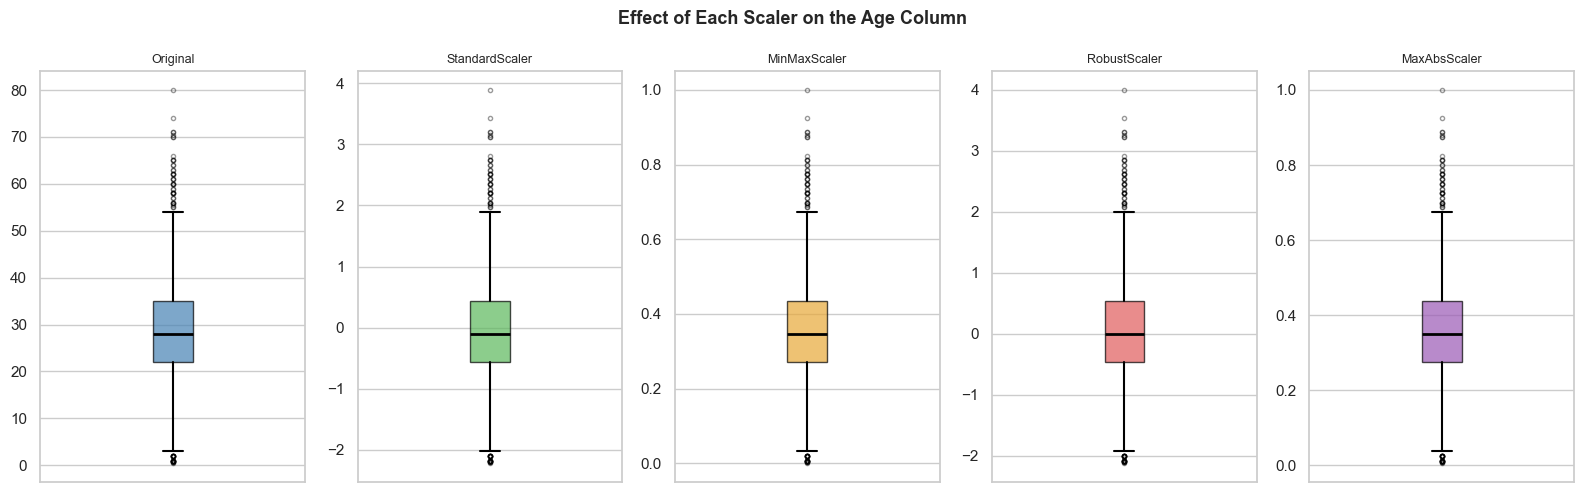

In [18]:

age_col = X[["age"]].copy()
imp_age = SimpleImputer(strategy="median")
age_imputed = imp_age.fit_transform(age_col)

scalers = {
    "Original":      age_imputed,
    "StandardScaler": StandardScaler().fit_transform(age_imputed),
    "MinMaxScaler":   MinMaxScaler().fit_transform(age_imputed),
    "RobustScaler":   RobustScaler().fit_transform(age_imputed),
    "MaxAbsScaler":   MaxAbsScaler().fit_transform(age_imputed),
}

fig, axes = plt.subplots(1, 5, figsize=(16, 5))
fig.suptitle("Effect of Each Scaler on the Age Column", fontsize=13, fontweight="bold")

colors = ["steelblue", "#5cb85c", "#e8a838", "#e05c5c", "#9b59b6"]
for ax, (name, data), color in zip(axes, scalers.items(), colors):
    ax.boxplot(data, patch_artist=True,
               boxprops=dict(facecolor=color, alpha=0.7),
               medianprops=dict(color="black", linewidth=2),
               whiskerprops=dict(linewidth=1.5),
               capprops=dict(linewidth=1.5),
               flierprops=dict(marker="o", markersize=3, alpha=0.4))
    ax.set_title(name, fontsize=9)
    ax.set_xticks([])

plt.tight_layout()
plt.show()

# **12) Categorical Encoding**

## 12.1) pd.get_dummies(..., drop_first=True) — One-Hot Encoding with Pandas

Machine learning models cannot directly work with text labels like `"male"` or `"female"`.
**One-hot encoding** converts each category into its own binary column (0 or 1).

`drop_first=True` removes one binary column per feature to avoid **multicollinearity**.

Here is the problem: if a passenger is not `male`, they must be `female`. So knowing all other columns makes the dropped column completely redundant — it carries zero new information. Linear models get confused by perfectly redundant columns because they cannot determine which one is actually driving the prediction. Dropping one column per feature prevents this.

In [19]:
# cat_cols contains the categorical column names: sex, embarked, who, deck
# (defined earlier using X.select_dtypes(exclude=[np.number]))

# Apply one-hot encoding to all categorical columns
X_dummies = pd.get_dummies(X, columns=cat_cols, drop_first=True)

print("Shape before encoding:", X.shape)
print("Shape after encoding: ", X_dummies.shape)
print()
X_dummies.head()

Shape before encoding: (891, 8)
Shape after encoding:  (891, 15)



,pclass,age,sibsp,parch,sex_male,embarked_Q,embarked_S,who_man,who_woman,deck_B,deck_C,deck_D,deck_E,deck_F,deck_G
0,3,22.0,1,0,True,False,True,True,False,False,False,False,False,False,False
1,1,38.0,1,0,False,False,False,False,True,False,True,False,False,False,False
2,3,26.0,0,0,False,False,True,False,True,False,False,False,False,False,False
3,1,35.0,1,0,False,False,True,False,True,False,True,False,False,False,False
4,3,35.0,0,0,True,False,True,True,False,False,False,False,False,False,False


**Note:**

For a column with N unique categories, `get_dummies` creates:
- N binary columns if `drop_first=False`
- N-1 binary columns if `drop_first=True`

The dropped column is implied: if all other columns are 0, the original category must be the dropped one.
This avoids the **dummy variable trap** in linear models.

## 12.2) OneHotEncoder — sklearn One-Hot Encoding

`OneHotEncoder` from scikit-learn does the same thing as `pd.get_dummies` but integrates into
sklearn pipelines. The key advantage is `handle_unknown="ignore"` — if the test set contains
a category that was never seen during training, the encoder won't crash; it just outputs all zeros
for that sample.

In [20]:
ohe = OneHotEncoder(handle_unknown="ignore", sparse_output=False)

# Fit and transform categorical columns
X_ohe = ohe.fit_transform(X[cat_cols])

# get_feature_names_out() gives readable column names like "sex_male", "embarked_S"
ohe_df = pd.DataFrame(X_ohe, columns=ohe.get_feature_names_out(cat_cols))

print("Encoded shape:", ohe_df.shape)
ohe_df.head()

Encoded shape: (891, 17)


,sex_female,sex_male,embarked_C,embarked_Q,embarked_S,embarked_nan,who_child,who_man,who_woman,deck_A,deck_B,deck_C,deck_D,deck_E,deck_F,deck_G,deck_nan
0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
1,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
2,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
3,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
4,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0


## 12.3) OrdinalEncoder — Integer Encoding (With Order)

`OrdinalEncoder` converts each category into an integer (0, 1, 2...).
Unlike one-hot encoding, it creates **one column per feature** instead of N columns.

This is appropriate for features where the categories have a natural ordering
(e.g., `pclass`: 1st > 2nd > 3rd). For unordered categories, use one-hot encoding instead,
because ordinal encoding implies a numerical relationship that may not exist.

In [21]:
ord_enc = OrdinalEncoder(
    handle_unknown="use_encoded_value",
    unknown_value=-1   # Assign -1 to any category not seen during training
)

X_ord = ord_enc.fit_transform(X[cat_cols])
pd.DataFrame(X_ord, columns=cat_cols).head()

,sex,embarked,who,deck
0,1.0,2.0,1.0,NaN
1,0.0,0.0,2.0,2.0
2,0.0,2.0,2.0,NaN
3,0.0,2.0,2.0,2.0
4,1.0,2.0,1.0,NaN


**Note:**

You will notice `NaN` values in the output for the `deck` column — `OrdinalEncoder` preserves missing values as-is. It does not fill them.

In a real pipeline, always impute missing values **before** encoding. The full Pipeline in **Section 20.1** handles this automatically by running the imputer step before the encoder step.

## 12.4) LabelEncoder — Integer Encoding for a Single Column

`LabelEncoder` is similar to `OrdinalEncoder` but designed for a **single column** at a time.
It is most commonly used to encode the **target variable** `y` rather than input features.

In [22]:
le = LabelEncoder()

# Encode the "sex" column as a standalone example
sex_encoded = le.fit_transform(X["sex"].fillna("unknown"))

print("Original values:", X["sex"].unique())
print("Encoded values: ", le.classes_, "->", le.transform(le.classes_))
print()
print("First 10 encoded values:", sex_encoded[:10])

Original values: ['male' 'female']
Encoded values:  ['female' 'male'] -> [0 1]

First 10 encoded values: [1 0 0 0 1 1 1 1 0 0]


**Note — Encoding Method Summary:**

| Method | Output | Best For |
|---|---|---|
| `get_dummies` / `OneHotEncoder` | N binary columns | Unordered categories, linear models |
| `OrdinalEncoder` | 1 integer column | Ordered categories (e.g., Low/Med/High) |
| `LabelEncoder` | 1 integer column | Target variable `y`, or single column encoding |

**Key rule:** For input features (`X`) with **no natural order**, always prefer one-hot encoding.
Ordinal/label encoding implies a numeric relationship between categories that does not exist
for unordered data — and that can mislead the model.

# **13) Train/Test Split and Preventing Data Leakage**

## 13.1) train_test_split with random_state — Regression

Splitting the data into training and test sets is fundamental to evaluating how well a model
generalizes to new, unseen data. `random_state` makes the split reproducible — you get
the same split every time you run the code.

In [23]:
# Naming convention used throughout the notebook:
# _r  = regression  (predicting the continuous fare value)
# _c  = classification  (predicting the binary survived value)

X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
    X, y_reg, test_size=0.2, random_state=42
)

print("Training set:", X_train_r.shape)
print("Test set:    ", X_test_r.shape)

Training set: (712, 8)
Test set:     (179, 8)


## 13.2) train_test_split with stratify — Classification

For classification, `stratify=y` ensures the class proportions are the same in both
the training and test sets. Without stratification, by random chance the test set might
end up with very different class ratios, giving you misleading evaluation results.

In [24]:
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X, y_clf, test_size=0.2, random_state=42, stratify=y_clf
)

# Verify the class proportions are similar in both sets
print("Train survival rate:", round(y_train_c.mean(), 3))
print("Test survival rate: ", round(y_test_c.mean(), 3))
print("(These should be similar — stratification worked if they are)")

Train survival rate: 0.383
Test survival rate:  0.385
(These should be similar — stratification worked if they are)


### Visual: Class Balance in Train vs Test Sets

Stratified splitting ensures the survival ratio is the same in both sets.
These two bars should look nearly identical — that is the goal of stratification.

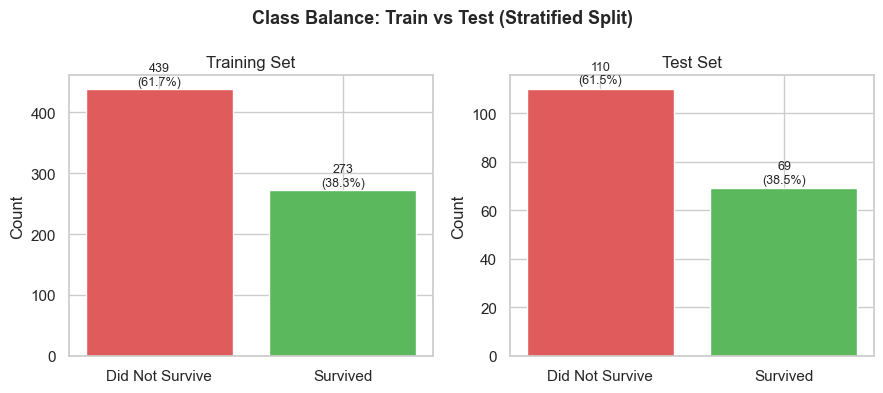

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(9, 4))
fig.suptitle("Class Balance: Train vs Test (Stratified Split)", fontsize=13, fontweight="bold")

for ax, y, title in [
    (axes[0], y_train_c, "Training Set"),
    (axes[1], y_test_c,  "Test Set")
]:
    counts = y.value_counts().sort_index()
    bars = ax.bar(["Did Not Survive", "Survived"], counts.values,
                  color=["#e05c5c", "#5cb85c"], edgecolor="white")
    ax.set_title(title)
    ax.set_ylabel("Count")
    for bar, val in zip(bars, counts.values):
        pct = val / len(y) * 100
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                f"{val}\n({pct:.1f}%)", ha="center", va="bottom", fontsize=9)

plt.tight_layout()
plt.show()

## 13.3) Fit Transformer on Train Only — Imputer

This is one of the most important concepts in preprocessing:
**Always fit transformers on training data only, then apply to both train and test.**

If you fit on the full dataset, information from the test set leaks into the training process.
This makes your model look better than it really is on unseen data.

In [26]:
imp = SimpleImputer(strategy="median")

# fit_transform on training data: learn medians FROM training data, then apply
X_train_imp = imp.fit_transform(X_train_r[num_cols])

# transform only on test data: apply the SAME training medians (do NOT re-fit)
X_test_imp  = imp.transform(X_test_r[num_cols])

print("Training medians learned by imputer:")
for col, val in zip(num_cols, imp.statistics_):
    print(f"  {col}: {val:.3f}")

Training medians learned by imputer:
  pclass: 3.000
  age: 28.000
  sibsp: 0.000
  parch: 0.000


## 13.4) Fit Transformer on Train Only — Scaler

Same principle as the imputer. The scaler learns mean and std from the training data only.
The test set is scaled using those training parameters — not its own.

In [27]:
scaler = StandardScaler()

# Use the imputer from Section 13.3 to fill missing values consistently
# (never use fillna(0) for features like age — zero is not a meaningful age)
X_train_scaled = scaler.fit_transform(X_train_imp)
X_test_scaled  = scaler.transform(X_test_imp)

print("Scaler learned from training data:")
for col, mean, std in zip(num_cols, scaler.mean_, scaler.scale_):
    print(f"  {col}: mean={mean:.2f}, std={std:.2f}")

Scaler learned from training data:
  pclass: mean=2.33, std=0.82
  age: mean=29.20, std=13.00
  sibsp: mean=0.55, std=1.18
  parch: mean=0.38, std=0.79


**Note — Why Data Leakage Matters:**

Imagine you are preparing a standardized exam. If students can see the answers before the exam,
they perform better than they would on a real unseen exam. That's data leakage.

When you fit a scaler on the full dataset (including test), the scaler has already "seen" the test
values when computing the mean and std. The model then appears to generalize well — but only because
the test data was embedded in the preprocessing step.

**The rule:** Fit only on training data. Apply to everything else.

# **16) Feature Validation and Selection**

## 16.1) Removing Constant or Low-Variance Features — VarianceThreshold

A feature that is the same value for every single row (constant) carries **zero information** —
the model cannot learn anything from it. Near-constant features (e.g., 99.9% the same value)
are almost equally useless.

`VarianceThreshold` from scikit-learn automatically removes features whose variance
falls below a threshold you specify.

In [28]:
# Prepare a clean numeric matrix (impute missing values first)
imp = SimpleImputer(strategy="median")
X_num_clean = pd.DataFrame(
    imp.fit_transform(X[num_cols]),
    columns=num_cols
)

# Inject a constant column to demonstrate — this carries zero information
X_num_clean["constant_col"] = 1.0
# near_constant: 890 rows are 0.0, only 1 row is 1.0
# This gives a very small variance (~0.001) that falls below the threshold — gets dropped
X_num_clean["near_constant"] = 0.0
X_num_clean.loc[X_num_clean.index[0], "near_constant"] = 1.0  # only 1 different value

print("Shape before VarianceThreshold:", X_num_clean.shape)
print("Variance of each column:")
print(X_num_clean.var().round(4))
print()

# Remove features with variance below 0.1
selector = VarianceThreshold(threshold=0.1)
X_var_filtered = selector.fit_transform(X_num_clean)

# Which columns survived?
survived_cols = X_num_clean.columns[selector.get_support()].tolist()
dropped_cols  = X_num_clean.columns[~selector.get_support()].tolist()

print("Columns kept:   ", survived_cols)
print("Columns dropped:", dropped_cols)
print("Shape after VarianceThreshold:", X_var_filtered.shape)

Shape before VarianceThreshold: (891, 6)
Variance of each column:
pclass             0.6990
age              169.5125
sibsp              1.2160
parch              0.6497
constant_col       0.0000
near_constant      0.0011
dtype: float64

Columns kept:    ['pclass', 'age', 'sibsp', 'parch']
Columns dropped: ['constant_col', 'near_constant']
Shape after VarianceThreshold: (891, 4)


**Note:**

`threshold=0.0` (the default) removes only **perfectly constant** columns (zero variance).
Increasing the threshold removes more features with low but non-zero variance.

Common uses:
- After one-hot encoding, some binary columns may be nearly all zeros (rare categories)
- After imputation, some columns may have been imputed with the same value for most rows

`selector.get_support()` returns a boolean array: `True` = column was kept, `False` = dropped.

### Visual: Feature Variance — Before and After VarianceThreshold

The bar chart shows the variance of each feature. The red dashed line marks
the threshold. Any bar below it gets removed.

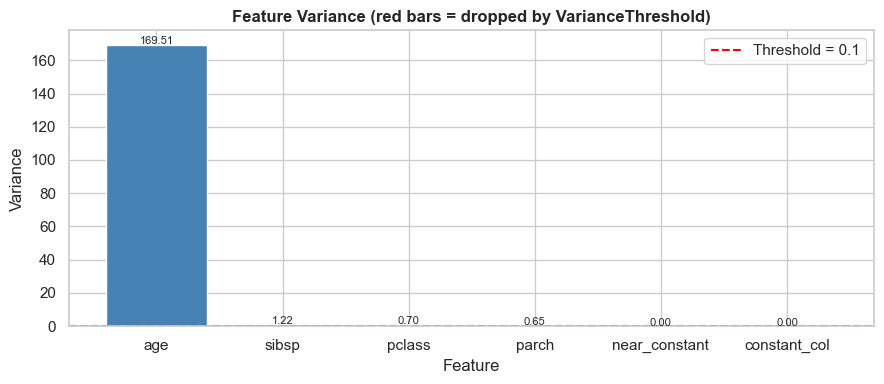

In [29]:
variances = X_num_clean.var().sort_values(ascending=False)
threshold_val = 0.1

fig, ax = plt.subplots(figsize=(9, 4))
colors_var = ["#e05c5c" if v < threshold_val else "steelblue" for v in variances.values]
bars = ax.bar(variances.index, variances.values, color=colors_var, edgecolor="white")
ax.axhline(threshold_val, color="red", linestyle="--", linewidth=1.5,
           label=f"Threshold = {threshold_val}")
ax.set_title("Feature Variance (red bars = dropped by VarianceThreshold)", fontsize=12, fontweight="bold")
ax.set_ylabel("Variance")
ax.set_xlabel("Feature")
ax.legend()
for bar, val in zip(bars, variances.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f"{val:.2f}", ha="center", fontsize=8)
plt.tight_layout()
plt.show()

## 16.2) Recursive Feature Elimination (RFE)

`RFE` (Recursive Feature Elimination) is a more powerful feature selection method.
It trains a model, ranks features by importance, removes the least important one,
and repeats — until only the number of features you specified remains.

This way, you keep only the features that actually help the model.

In [30]:

# Prepare a fully numeric, imputed dataset
imp = SimpleImputer(strategy="median")
X_num_imputed = pd.DataFrame(
    imp.fit_transform(X[num_cols]),
    columns=num_cols
)
y_clf_clean = y_clf.values

# Use Logistic Regression as the base model for importance ranking
base_model = LogisticRegression(max_iter=1000)

# Select the top 3 most important features
rfe = RFE(estimator=base_model, n_features_to_select=3)
rfe.fit(X_num_imputed, y_clf_clean)

# Show which features were selected
for feature, selected, rank in zip(num_cols, rfe.support_, rfe.ranking_):
    status = "SELECTED" if selected else f"rank {rank}"
    print(f"  {feature}: {status}")

  pclass: SELECTED
  age: rank 2
  sibsp: SELECTED
  parch: SELECTED


**Note:**

`RFE` requires a model that can rank features by importance.
Suitable models include:
- `LinearRegression` / `LogisticRegression` — use coefficient magnitude
- `RandomForestClassifier` / `DecisionTreeClassifier` — use feature importance scores

`rfe.support_` → boolean array: True = selected, False = eliminated
`rfe.ranking_` → 1 = selected, higher number = eliminated earlier (less important)

RFE is computationally expensive on large datasets because it retrains the model
in every iteration. For very wide datasets, consider `SelectFromModel` as a faster alternative.

### Visual: RFE Feature Rankings

The bar chart shows the RFE ranking of each feature.
Rank 1 (green) = selected. Higher rank = eliminated earlier = less important.

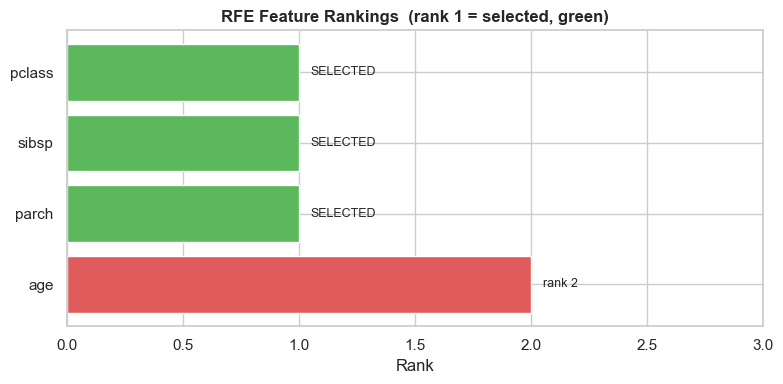

In [31]:
feature_ranks = dict(zip(num_cols, rfe.ranking_))
sorted_features = sorted(feature_ranks.items(), key=lambda x: x[1])
names  = [f[0] for f in sorted_features]
ranks  = [f[1] for f in sorted_features]
colors_rfe = ["#5cb85c" if r == 1 else "#e05c5c" for r in ranks]

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.barh(names, ranks, color=colors_rfe, edgecolor="white")
ax.set_title("RFE Feature Rankings  (rank 1 = selected, green)", fontsize=12, fontweight="bold")
ax.set_xlabel("Rank")
ax.invert_yaxis()
for bar, rank in zip(bars, ranks):
    label = "SELECTED" if rank == 1 else f"rank {rank}"
    ax.text(bar.get_width() + 0.05, bar.get_y() + bar.get_height()/2,
            label, va="center", fontsize=9)
ax.set_xlim(0, max(ranks) + 1)
plt.tight_layout()
plt.show()

# **17) Dimensionality Reduction**

## 17.1) PCA — Principal Component Analysis

**PCA** is a technique that reduces the number of features while preserving as much information
as possible. It does this by finding new axes (called **principal components**) that capture the
directions of maximum variance in the data.

Instead of keeping 5 original features that might overlap in what they measure, PCA combines them
into fewer, more informative components — with no two components carrying the same information.

Think of it as compressing a large image while keeping the most important visual details.

In [32]:
# Prepare clean numeric data
imp = SimpleImputer(strategy="median")
scaler = StandardScaler()

X_clean = imp.fit_transform(X[num_cols])
X_scaled = scaler.fit_transform(X_clean)

# Apply PCA — reduce 4 numeric features to 3 principal components
pca = PCA(n_components=3)
X_pca = pca.fit_transform(X_scaled)

print("Original shape:    ", X_scaled.shape)
print("After PCA shape:   ", X_pca.shape)
print()
print("Variance explained by each component:")
for i, var in enumerate(pca.explained_variance_ratio_):
    print(f"  PC{i+1}: {var:.2%}")
print(f"  Total: {pca.explained_variance_ratio_.sum():.2%}")

Original shape:     (891, 4)
After PCA shape:    (891, 3)

Variance explained by each component:
  PC1: 41.22%
  PC2: 28.62%
  PC3: 15.68%
  Total: 85.52%


**Note:**

`explained_variance_ratio_` tells you how much of the total information (variance) each
component captures.

For example:
- PC1 explains ~41% of variance → the single most important "direction" in the data
- PC2 explains ~29% → the second most important, completely independent of PC1
- PC3 explains ~16% → third most important
- Together, 3 components capture ~85.5% of the total information in 4 original features

Always **scale before PCA**. PCA is sensitive to feature magnitude — a feature with values
in the thousands will dominate components purely because of its scale, not its actual importance.

**When to use PCA:**
- When you have many correlated numeric features
- When you want to speed up training by reducing input dimensions
- For visualization (reducing to 2-3 components to plot high-dimensional data)

### Visual: PCA — Scree Plot and 2D Scatter

**Scree plot:** shows how much variance each principal component captures.
The cumulative line tells you how many components you need to retain a given % of information.

**2D Scatter:** plots every passenger as a point in the space of PC1 vs PC2,
coloured by survival. Separation between colours means PCA captured useful structure.

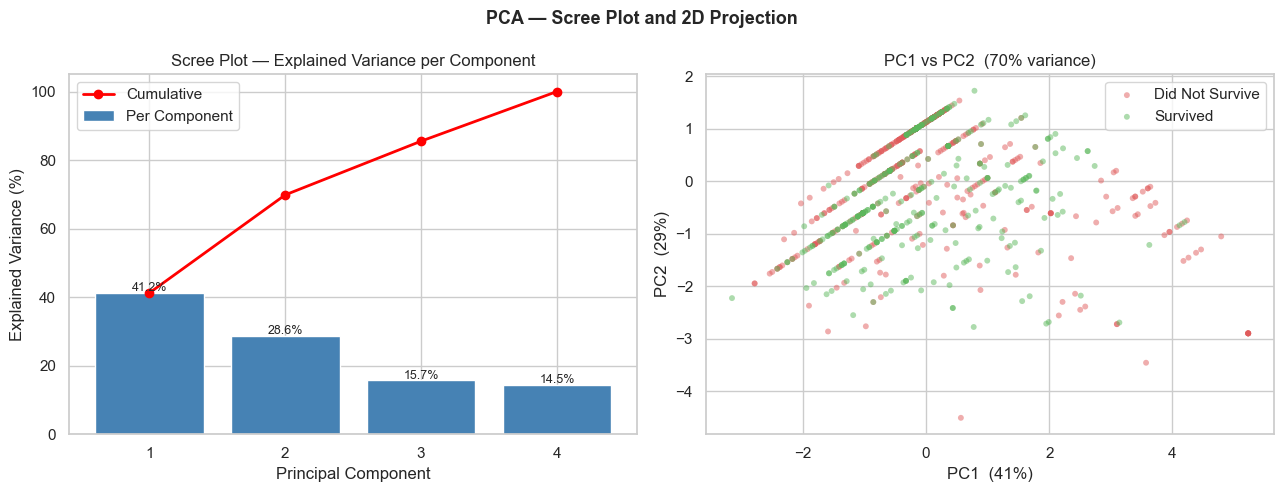

In [33]:
# Run PCA on all 4 numeric features (keep all components for scree plot)

imp_pca  = SimpleImputer(strategy="median")
scl_pca  = StandardScaler()
X_pca_input = scl_pca.fit_transform(imp_pca.fit_transform(X[num_cols]))

pca_full = PCA()
pca_full.fit(X_pca_input)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("PCA — Scree Plot and 2D Projection", fontsize=13, fontweight="bold")

# 1. Scree plot
n = len(pca_full.explained_variance_ratio_)
evr   = pca_full.explained_variance_ratio_
cumev = evr.cumsum()

axes[0].bar(range(1, n+1), evr * 100, color="steelblue", edgecolor="white", label="Per Component")
axes[0].plot(range(1, n+1), cumev * 100, color="red", marker="o", linewidth=2, label="Cumulative")
axes[0].set_title("Scree Plot — Explained Variance per Component")
axes[0].set_xlabel("Principal Component")
axes[0].set_ylabel("Explained Variance (%)")
axes[0].set_xticks(range(1, n+1))
axes[0].legend()
for i, (v, c) in enumerate(zip(evr, cumev)):
    axes[0].text(i+1, v*100 + 0.5, f"{v*100:.1f}%", ha="center", fontsize=9)

# 2. 2D scatter coloured by survival
pca_2d = PCA(n_components=2)
X_2d = pca_2d.fit_transform(X_pca_input)

colors_pca = ["#e05c5c", "#5cb85c"]
labels_pca  = ["Did Not Survive", "Survived"]
for cls, color, label in zip([0, 1], colors_pca, labels_pca):
    mask = y_clf.values == cls
    axes[1].scatter(X_2d[mask, 0], X_2d[mask, 1], c=color, label=label,
                    alpha=0.5, s=18, edgecolors="none")

axes[1].set_title(f"PC1 vs PC2  ({pca_2d.explained_variance_ratio_.sum():.0%} variance)")
axes[1].set_xlabel(f"PC1  ({pca_2d.explained_variance_ratio_[0]:.0%})")
axes[1].set_ylabel(f"PC2  ({pca_2d.explained_variance_ratio_[1]:.0%})")
axes[1].legend()

plt.tight_layout()
plt.show()

## 17.2) Truncated SVD — Dimensionality Reduction for Sparse Data

**TruncatedSVD** (Singular Value Decomposition) works similarly to PCA but is designed for
**sparse matrices** — matrices with many zero values, which are common after one-hot encoding.

While PCA requires centering the data (which destroys sparsity), TruncatedSVD works directly
on the raw sparse matrix.

In [34]:
# After one-hot encoding, we have a sparse-like matrix
ohe = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
X_encoded = ohe.fit_transform(X[cat_cols])

print("One-hot encoded shape:", X_encoded.shape)
print()

# Apply TruncatedSVD to reduce to 5 components
svd = TruncatedSVD(n_components=5, random_state=42)
X_svd = svd.fit_transform(X_encoded)

print("After TruncatedSVD shape:", X_svd.shape)
print()
print("Variance explained by each component:")
for i, var in enumerate(svd.explained_variance_ratio_):
    print(f"  Component {i+1}: {var:.2%}")
print(f"  Total: {svd.explained_variance_ratio_.sum():.2%}")

One-hot encoded shape: (891, 17)

After TruncatedSVD shape: (891, 5)

Variance explained by each component:
  Component 1: 12.18%
  Component 2: 39.98%
  Component 3: 15.27%
  Component 4: 10.16%
  Component 5: 6.79%
  Total: 84.38%


**Note:**

| | PCA | TruncatedSVD |
|---|---|---|
| Data type | Dense numeric | Sparse or dense |
| Centering required | Yes | No |
| Best for | Scaled numeric features | One-hot encoded / text features |
| Speed on sparse data | Slow (centering fills zeros) | Fast |

Both PCA and TruncatedSVD are **unsupervised** — they don't use the target variable `y`.
They simply find the most information-dense directions in the feature space.

### Visual: TruncatedSVD — Explained Variance per Component

Same idea as the PCA scree plot but applied to the one-hot encoded categorical features.
Each bar represents how much information one SVD component captures.

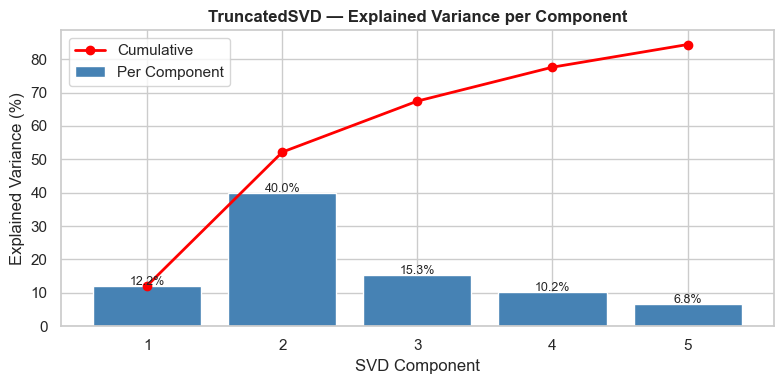

In [35]:
fig, ax = plt.subplots(figsize=(8, 4))
evr_svd  = svd.explained_variance_ratio_
cumev_svd = evr_svd.cumsum()
n_svd = len(evr_svd)

ax.bar(range(1, n_svd+1), evr_svd * 100, color="steelblue", edgecolor="white", label="Per Component")
ax.plot(range(1, n_svd+1), cumev_svd * 100, color="red", marker="o", linewidth=2, label="Cumulative")
ax.set_title("TruncatedSVD — Explained Variance per Component", fontsize=12, fontweight="bold")
ax.set_xlabel("SVD Component")
ax.set_ylabel("Explained Variance (%)")
ax.set_xticks(range(1, n_svd+1))
ax.legend()
for i, v in enumerate(evr_svd):
    ax.text(i+1, v*100 + 0.3, f"{v*100:.1f}%", ha="center", fontsize=9)
plt.tight_layout()
plt.show()

# **18) Handling Class Imbalance — SMOTE**

## 18.1) Understanding Class Imbalance — SMOTE

**Class imbalance** occurs when one class in a classification problem has far more samples
than the other. In the Titanic dataset, 549 passengers did not survive vs 342 who did —
roughly a 62/38 split.

If a model just predicts "did not survive" for every single passenger, it gets 62% accuracy
without learning anything useful. Class imbalance tricks models into being lazy.

There are two main strategies:
1. **Oversampling** — generate more synthetic samples for the minority class (what SMOTE does)
2. **Undersampling** — remove samples from the majority class

SMOTE (Synthetic Minority Over-sampling Technique) creates **new synthetic samples** for the
minority class by interpolating between existing minority samples — not just duplicating them.

In [36]:
# Prepare clean numeric data (SMOTE only works on numeric input)
imp = SimpleImputer(strategy="median")
X_num_clean = pd.DataFrame(
    imp.fit_transform(X[num_cols]),
    columns=num_cols
)

y_clean = y_clf.values

print("Class distribution BEFORE SMOTE:")
unique, counts = np.unique(y_clean, return_counts=True)
for cls, cnt in zip(unique, counts):
    print(f"  Class {cls}: {cnt} samples ({cnt/len(y_clean):.1%})")
print()

# Apply SMOTE — oversample the minority class (survived=1) to balance with majority
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X_num_clean, y_clean)

print("Class distribution AFTER SMOTE:")
unique, counts = np.unique(y_resampled, return_counts=True)
for cls, cnt in zip(unique, counts):
    print(f"  Class {cls}: {cnt} samples ({cnt/len(y_resampled):.1%})")
print()
print("Shape before SMOTE:", X_num_clean.shape)
print("Shape after SMOTE: ", X_resampled.shape)

Class distribution BEFORE SMOTE:
  Class 0: 549 samples (61.6%)
  Class 1: 342 samples (38.4%)

Class distribution AFTER SMOTE:
  Class 0: 549 samples (50.0%)
  Class 1: 549 samples (50.0%)

Shape before SMOTE: (891, 4)
Shape after SMOTE:  (1098, 4)


**Note:**

SMOTE creates **new synthetic samples** by:
1. Taking a minority class sample
2. Finding its k nearest minority class neighbors
3. Randomly interpolating between the sample and one of its neighbors

This is better than simple duplication (which just repeats existing rows) because it
introduces **diversity** into the minority class.

**Important rules for SMOTE:**
- Apply SMOTE **only on training data** — never on test data
- SMOTE requires numeric input only — encode categoricals first
- SMOTE is applied **after** the train/test split — the test set should reflect the real imbalanced distribution

**When to use SMOTE:**
- Binary or multi-class classification with significant imbalance (typically > 3:1 ratio)
- When you want the model to detect minority class patterns, not just default to the majority

### Visual: Class Balance Before and After SMOTE

SMOTE brings the minority class up to match the majority class.
These two charts make the before/after balance immediately visible.

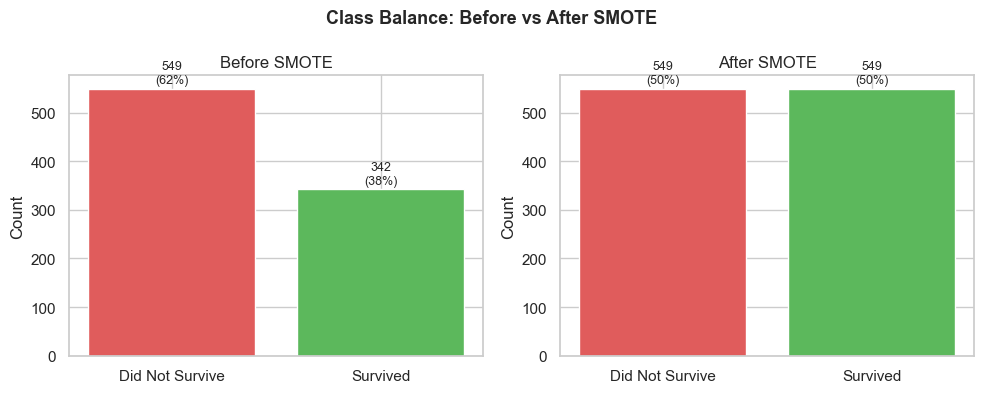

In [37]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
fig.suptitle("Class Balance: Before vs After SMOTE", fontsize=13, fontweight="bold")

for ax, y_data, title in [
    (axes[0], y_clean,      "Before SMOTE"),
    (axes[1], y_resampled,  "After SMOTE")
]:
    # Count how many samples belong to each class
    count_0 = int((y_data == 0).sum())
    count_1 = int((y_data == 1).sum())
    total   = count_0 + count_1

    bars = ax.bar(["Did Not Survive", "Survived"], [count_0, count_1],
                  color=["#e05c5c", "#5cb85c"], edgecolor="white")
    ax.set_title(title)
    ax.set_ylabel("Count")

    # Add count and percentage label on each bar
    for bar, val in zip(bars, [count_0, count_1]):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
                f"{val}\n({val/total:.0%})", ha="center", va="bottom", fontsize=9)

plt.tight_layout()
plt.show()

# **20) Prebuilt sklearn Workflow — Pipelines**

## 20.1) ColumnTransformer — Different Steps for Different Column Types

In real ML workflows, numeric and categorical columns need different preprocessing:
- Numeric → impute missing values + scale
- Categorical → impute missing values + one-hot encode

`ColumnTransformer` applies the right pipeline to the right columns in one clean step.

In [38]:
numeric_features     = num_cols
categorical_features = cat_cols.tolist()

# Pipeline for numeric columns: impute then scale
numeric_pipe = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler",  StandardScaler())
])

# Pipeline for categorical columns: impute then one-hot encode
categorical_pipe = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot",  OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])

# Combine both pipelines
preprocess = ColumnTransformer(
    transformers=[
        ("num", numeric_pipe,     numeric_features),
        ("cat", categorical_pipe, categorical_features)
    ],
    remainder="drop"
)

preprocess

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``. e.g. `

**Note:**

A **Pipeline** chains steps sequentially — each step's output is the next step's input.
A **ColumnTransformer** runs multiple pipelines in parallel on different column groups.

Together they create a single preprocessing object that:
- Handles all column types
- Applies steps in the correct order
- Fits only on training data and applies consistently to test data
- Prevents data leakage

`remainder="drop"` means any column not explicitly listed is discarded from the output.

## 20.2) Full Pipeline — Preprocessing + Linear Regression

By including the model inside the Pipeline, the entire workflow (preprocessing + training) is
encapsulated in one object. This is how production ML systems are typically structured.

In [39]:
lin_pipe = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model",      LinearRegression())
])

# Fit the entire pipeline on training data
lin_pipe.fit(X_train_r, y_train_r)

# Predict on test data
y_pred_reg = lin_pipe.predict(X_test_r)

print("Linear Regression Results:")
print(f"  R2 Score: {r2_score(y_test_r, y_pred_reg):.4f}")
print(f"  RMSE:     {np.sqrt(mean_squared_error(y_test_r, y_pred_reg)):.4f}")

Linear Regression Results:
  R2 Score: 0.5067
  RMSE:     27.6295


### Visual: Actual vs Predicted Fare (Linear Regression)

The scatter plot shows predicted fare on the x-axis vs actual fare on the y-axis.
A perfect model would put every point on the red diagonal line.
Points scattered around the line show where the model over- or under-predicts.

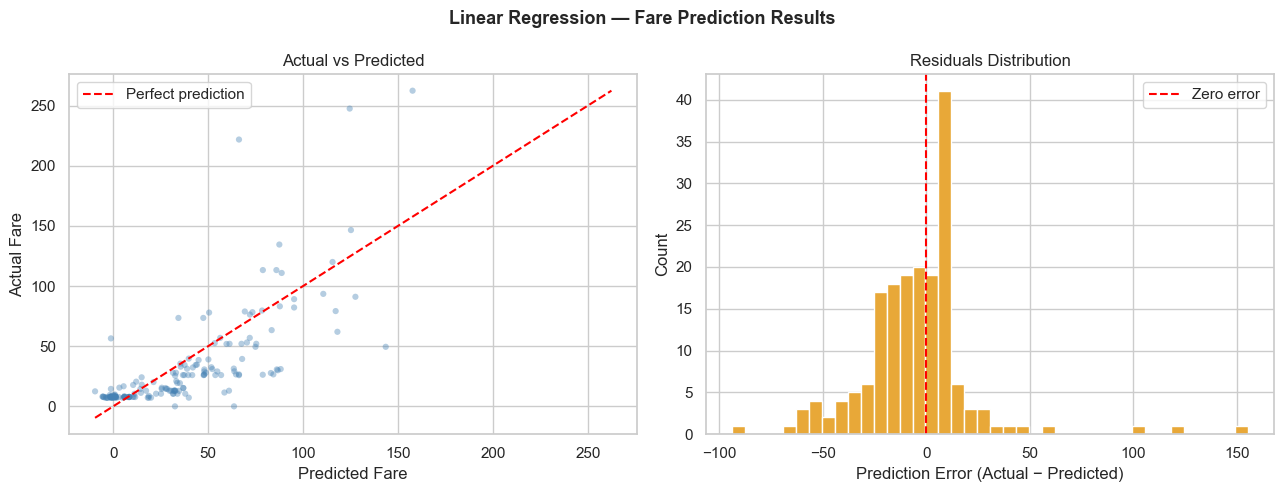

In [40]:
y_pred_plot = lin_pipe.predict(X_test_r)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("Linear Regression — Fare Prediction Results", fontsize=13, fontweight="bold")

# 1. Actual vs Predicted scatter
axes[0].scatter(y_pred_plot, y_test_r, alpha=0.4, color="steelblue", s=20, edgecolors="none")
min_val = min(y_pred_plot.min(), y_test_r.min())
max_val = max(y_pred_plot.max(), y_test_r.max())
axes[0].plot([min_val, max_val], [min_val, max_val], color="red", linewidth=1.5,
             linestyle="--", label="Perfect prediction")
axes[0].set_xlabel("Predicted Fare")
axes[0].set_ylabel("Actual Fare")
axes[0].set_title("Actual vs Predicted")
axes[0].legend()

# 2. Residuals distribution
residuals = y_test_r.values - y_pred_plot
axes[1].hist(residuals, bins=40, color="#e8a838", edgecolor="white")
axes[1].axvline(0, color="red", linestyle="--", linewidth=1.5, label="Zero error")
axes[1].set_title("Residuals Distribution")
axes[1].set_xlabel("Prediction Error (Actual − Predicted)")
axes[1].set_ylabel("Count")
axes[1].legend()

plt.tight_layout()
plt.show()

## 20.3) Full Pipeline — Preprocessing + Logistic Regression

This pipeline does exactly the same thing as the linear regression pipeline above, but the final step is a `LogisticRegression` model instead.

Because logistic regression is sensitive to feature scale, the scaling step inside the pipeline is especially important here — it ensures all numeric features are on the same scale before the model tries to learn from them.

The entire preprocessing + training workflow is still a single `.fit()` call.

In [41]:
log_pipe = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model",      LogisticRegression(max_iter=2000))
])

log_pipe.fit(X_train_c, y_train_c)
y_pred_clf = log_pipe.predict(X_test_c)

print("Logistic Regression Results:")
print(f"  Accuracy: {accuracy_score(y_test_c, y_pred_clf):.4f}")
print()
print(classification_report(y_test_c, y_pred_clf))

Logistic Regression Results:
  Accuracy: 0.8045

              precision    recall  f1-score   support

           0       0.81      0.89      0.85       110
           1       0.79      0.67      0.72        69

    accuracy                           0.80       179
   macro avg       0.80      0.78      0.79       179
weighted avg       0.80      0.80      0.80       179



**Note:**

When you call `pipeline.fit(X_train, y_train)`:
1. Each preprocessing step calls `fit_transform()` on the training data
2. The output of preprocessing is passed directly to the model's `fit()`

When you call `pipeline.predict(X_test)`:
1. Each preprocessing step calls `transform()` (NOT `fit_transform()`) on the test data
2. The same learned parameters from training are used — no relearning
3. The preprocessed test data is passed to the model's `predict()`

This design ensures **zero data leakage** and **consistent preprocessing** at inference time.

### Visual: Confusion Matrix (Logistic Regression)

A confusion matrix shows exactly where the model is right and where it makes mistakes.

- **Top-left:** True Negatives — correctly predicted 'did not survive'
- **Top-right:** False Positives — predicted 'survived' but actually didn't
- **Bottom-left:** False Negatives — predicted 'did not survive' but actually survived
- **Bottom-right:** True Positives — correctly predicted 'survived'

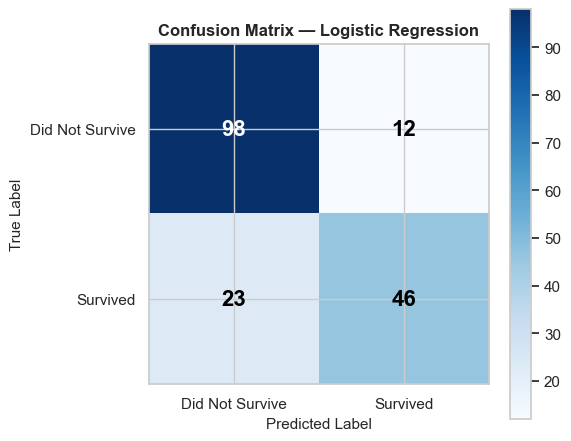

In [42]:
cm = confusion_matrix(y_test_c, log_pipe.predict(X_test_c))
labels = ["Did Not Survive", "Survived"]

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(cm, cmap="Blues")
plt.colorbar(im, ax=ax)

ax.set_xticks([0, 1]); ax.set_xticklabels(labels)
ax.set_yticks([0, 1]); ax.set_yticklabels(labels)
ax.set_xlabel("Predicted Label", fontsize=11)
ax.set_ylabel("True Label", fontsize=11)
ax.set_title("Confusion Matrix — Logistic Regression", fontsize=12, fontweight="bold")

for i in range(2):
    for j in range(2):
        ax.text(j, i, cm[i, j], ha="center", va="center",
                color="white" if cm[i, j] > cm.max() / 2 else "black",
                fontsize=16, fontweight="bold")

plt.tight_layout()
plt.show()

# **21) Saving and Loading Models**

## 21.1) joblib.dump() — Save the Trained Pipeline

In real deployments, you train once and then reuse the model many times.
`joblib.dump()` serializes (saves) the entire pipeline — including all learned preprocessing
parameters and the trained model — into a single file.

**What does "serialize" mean?**

Think of it like taking a detailed photograph of the trained model — every weight, every learned parameter, every preprocessing statistic. The `.joblib` file stores that photograph. When you load it later, you restore the model to its exact trained state.

**Important:** A pipeline saved with one version of scikit-learn may not load correctly in a significantly different version. Always note which version you used when saving a model for production use (`sklearn.__version__`).

In [43]:
# Saves to the current working directory — the same folder as this notebook
# You can verify by checking that file in your file explorer after running this cell

# Save both trained pipelines to disk
joblib.dump(log_pipe, "titanic_logistic_pipeline.joblib")
joblib.dump(lin_pipe, "titanic_linear_pipeline.joblib")

print("Pipelines saved successfully.")

# For GitHub projects: add the following line to your .gitignore file
# to avoid committing large binary model files to version control:
#   *.joblib

Pipelines saved successfully.


## 21.2) joblib.load() — Load and Reuse a Saved Pipeline

`joblib.load()` reads the saved file and restores the full pipeline object exactly as it was —
with all preprocessing parameters and model weights intact. You can immediately use it to predict.

In [44]:
# Load the saved pipelines
loaded_log = joblib.load("titanic_logistic_pipeline.joblib")
loaded_lin  = joblib.load("titanic_linear_pipeline.joblib")

# Predict using the loaded pipelines — no retraining needed
print("Logistic predictions (first 5):", loaded_log.predict(X_test_c.head()))
print("Linear predictions  (first 5):", loaded_lin.predict(X_test_r.head()).round(2))

Logistic predictions (first 5): [0 0 0 0 1]
Linear predictions  (first 5): [36.68 31.19  0.71 34.36 15.11]


**Note:**

`joblib` is preferred over Python's built-in `pickle` for sklearn objects because:
- It is more efficient for large NumPy arrays
- It handles model objects more reliably

The saved `.joblib` file contains everything:
- Imputer statistics (learned medians, modes)
- Scaler parameters (mean, std, min, max)
- Encoder mappings (category → integer or one-hot)
- Model weights and coefficients

This means the exact same preprocessing will always be applied consistently — no matter when or where
the model is loaded and used.